In [1]:
# =====================================================================
#  Visualization Notebook – Imports & Configuration
# =====================================================================
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

CONFIG = {
    "DATA_ROOT":     "./prepareddata",
    "TRAINED_ROOT":  "./trained",
    "OUTPUT_DIR":    "./trained/visualizations",
    "XAI_DIR":       "./trained/xai",
    "RANDOM_STATE":  42,
}
Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)
print(f"[config] Figures will be saved to {CONFIG['OUTPUT_DIR']}")

[config] Figures will be saved to ./trained/visualizations


In [2]:
# =====================================================================
#  Load saved results and build a unified comparison table
# =====================================================================
res_path = Path(CONFIG["TRAINED_ROOT"]) / "optimized_hybrid" / "optimized_hybrid_results.csv"
results_df = pd.read_csv(res_path)

# ---------------------------
# 1. Best optimized strategy per dataset
# ---------------------------
opt_best = results_df.loc[results_df.groupby(["dataset", "selection_strategy"])["f1"].idxmax()].reset_index(drop=True)
opt_best = opt_best[["dataset", "selection_strategy", "meta_learner", "f1", "n_models", "strategy_time_sec"]]
opt_best.rename(columns={"selection_strategy": "strategy", "strategy_time_sec": "time_sec"}, inplace=True)

# Rename strategies for display
strategy_map = {
    "fraud_coverage": "Fraud Coverage",
    "balanced": "Balanced Greedy",
    "exhaustive": "Exhaustive Search",
    "diverse_cv": "Diverse CV",
    "coverage_balanced": "Coverage Balanced",
}
opt_best["strategy"] = opt_best["strategy"].map(strategy_map)

# ---------------------------
# 2. Naive Stack baseline (from leaderboards)
# ---------------------------
leaderboard_dir = Path(CONFIG["TRAINED_ROOT"]) / "leaderboards"
naive_rows = []
for ds in opt_best["dataset"].unique():
    l1_file = leaderboard_dir / f"{ds}_top3_L1_by_f1.csv"
    if not l1_file.exists():
        continue
    l1 = pd.read_csv(l1_file)
    best_l1 = l1.loc[l1["f1"].idxmax()]

    # Determine number of base models used by the naive stack (from meta-features)
    variant = best_l1["variant"]
    meta_file = Path(CONFIG["TRAINED_ROOT"]) / ds / variant / "test_meta_features.csv"
    if meta_file.exists():
        n_models = pd.read_csv(meta_file).shape[1]  # number of base model columns
    else:
        n_models = np.nan

    naive_rows.append({
        "dataset": ds,
        "strategy": "Naive Stack",
        "meta_learner": "Various",   # not tracked; we can set to "Meta-Learner"
        "f1": best_l1["f1"],
        "n_models": n_models,
        "time_sec": np.nan,
    })

naive_df = pd.DataFrame(naive_rows)

# ---------------------------
# 3. Combine into one DataFrame
# ---------------------------
comparison_df = pd.concat([naive_df, opt_best], ignore_index=True)

print("[load] Unified comparison table:")
print(comparison_df.to_string(index=False))

[load] Unified comparison table:
     dataset          strategy    meta_learner       f1  n_models    time_sec
EuropeanCard       Naive Stack         Various 0.844444        14         NaN
    IEEE-CIS       Naive Stack         Various 0.464791        14         NaN
     Sparkov       Naive Stack         Various 0.779389        14         NaN
EuropeanCard   Balanced Greedy RidgeClassifier 0.854962         2    4.124261
EuropeanCard Coverage Balanced RidgeClassifier 0.821705         3    6.184481
EuropeanCard        Diverse CV    RandomForest 0.835821         2  902.608891
EuropeanCard Exhaustive Search             MLP 0.837209         5    5.177049
EuropeanCard    Fraud Coverage       LinearSVC 0.850746         2    3.904410
    IEEE-CIS   Balanced Greedy        LightGBM 0.452294         2    6.760307
    IEEE-CIS Coverage Balanced             MLP 0.454692         5   10.403916
    IEEE-CIS        Diverse CV        LightGBM 0.458153         4 2157.078963
    IEEE-CIS Exhaustive Search 

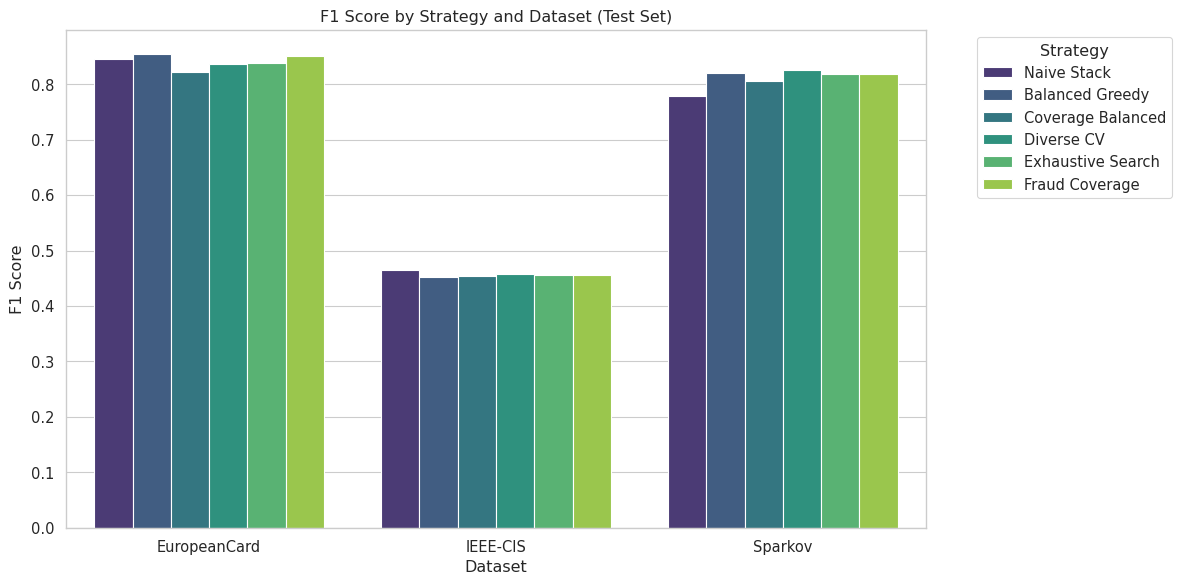

[save] trained/visualizations/f1_comparison_all_strategies.png


In [3]:
# =====================================================================
#  Figure 1: F1 Score Comparison Across Strategies and Datasets
# =====================================================================
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="dataset", y="f1", hue="strategy", palette="viridis")
plt.title("F1 Score by Strategy and Dataset (Test Set)")
plt.ylabel("F1 Score")
plt.xlabel("Dataset")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Strategy")
plt.tight_layout()
save_path = Path(CONFIG["OUTPUT_DIR"]) / "f1_comparison_all_strategies.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[save] {save_path}")

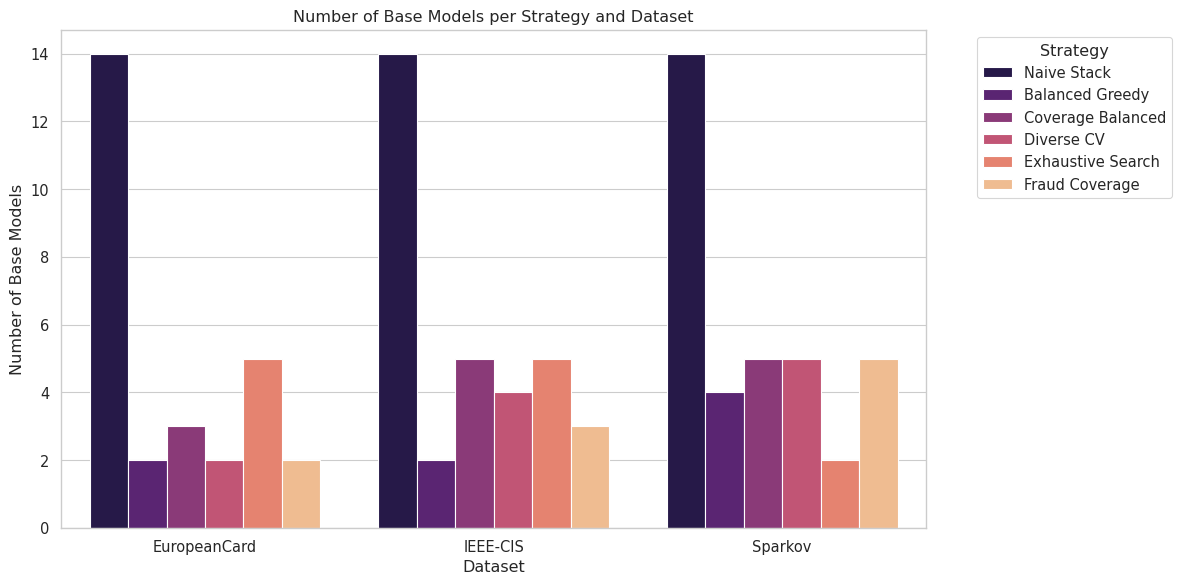

[save] trained/visualizations/n_models_comparison.png


In [4]:
# =====================================================================
#  Figure 2: Number of Base Models Used by Each Strategy
# =====================================================================
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="dataset", y="n_models", hue="strategy", palette="magma")
plt.title("Number of Base Models per Strategy and Dataset")
plt.ylabel("Number of Base Models")
plt.xlabel("Dataset")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Strategy")
plt.tight_layout()
save_path = Path(CONFIG["OUTPUT_DIR"]) / "n_models_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[save] {save_path}")

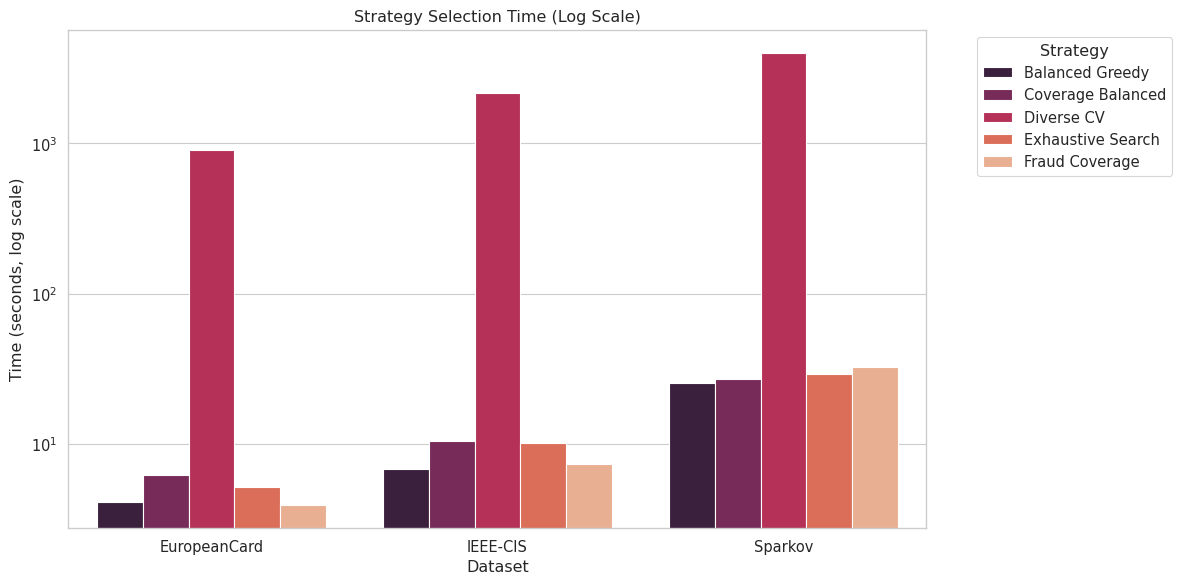

[save] trained/visualizations/strategy_time_comparison.png


In [5]:
# =====================================================================
#  Figure 3: Selection Time by Strategy (Log Scale)
# =====================================================================
time_df = comparison_df[comparison_df["strategy"] != "Naive Stack"].dropna(subset=["time_sec"])
if not time_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=time_df, x="dataset", y="time_sec", hue="strategy", palette="rocket")
    plt.yscale("log")
    plt.title("Strategy Selection Time (Log Scale)")
    plt.ylabel("Time (seconds, log scale)")
    plt.xlabel("Dataset")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Strategy")
    plt.tight_layout()
    save_path = Path(CONFIG["OUTPUT_DIR"]) / "strategy_time_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[save] {save_path}")
else:
    print("[skip] No time data available.")


[plot] ROC/PR for EuropeanCard


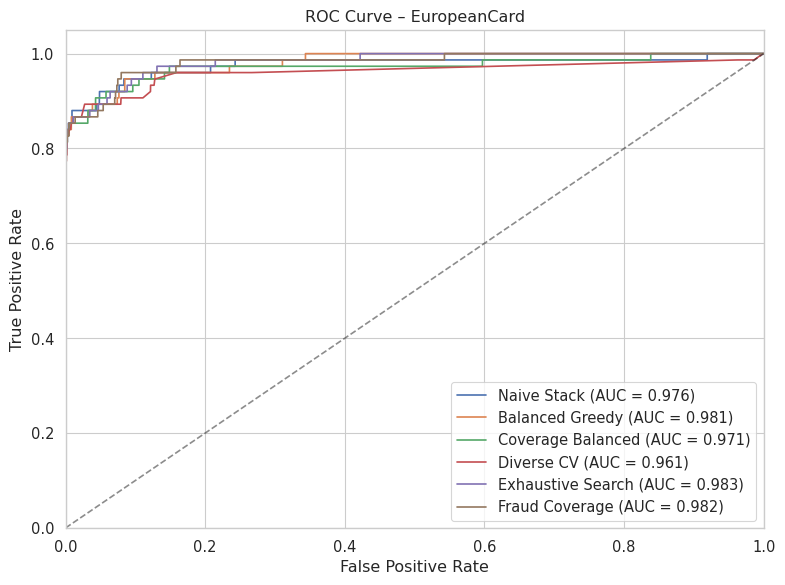

[save] trained/visualizations/roc_EuropeanCard.png


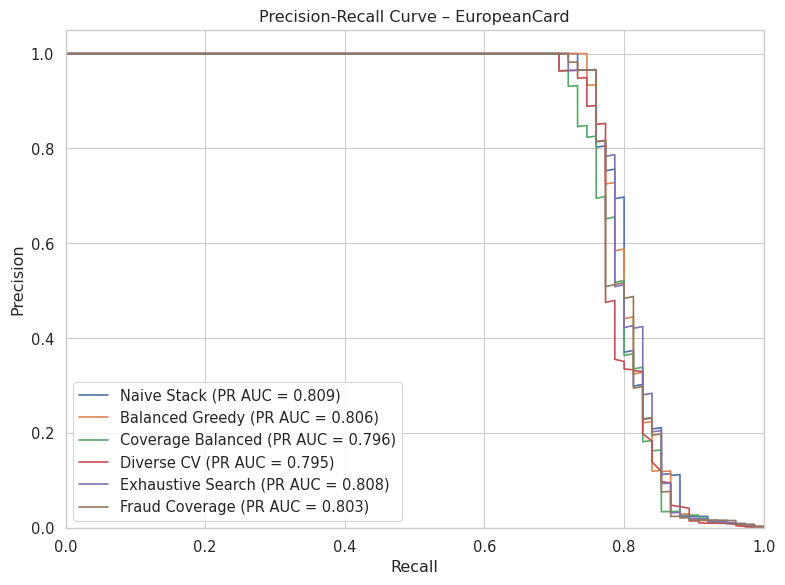

[save] trained/visualizations/pr_EuropeanCard.png

[plot] ROC/PR for IEEE-CIS


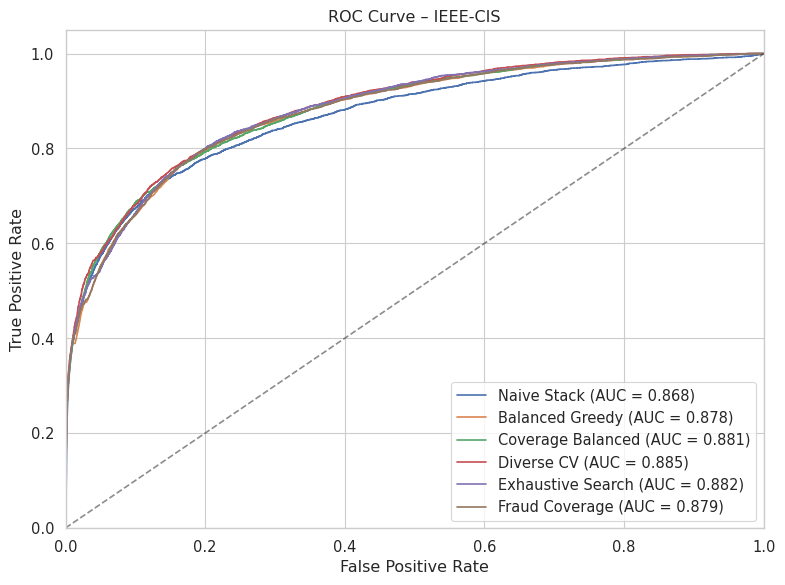

[save] trained/visualizations/roc_IEEE-CIS.png


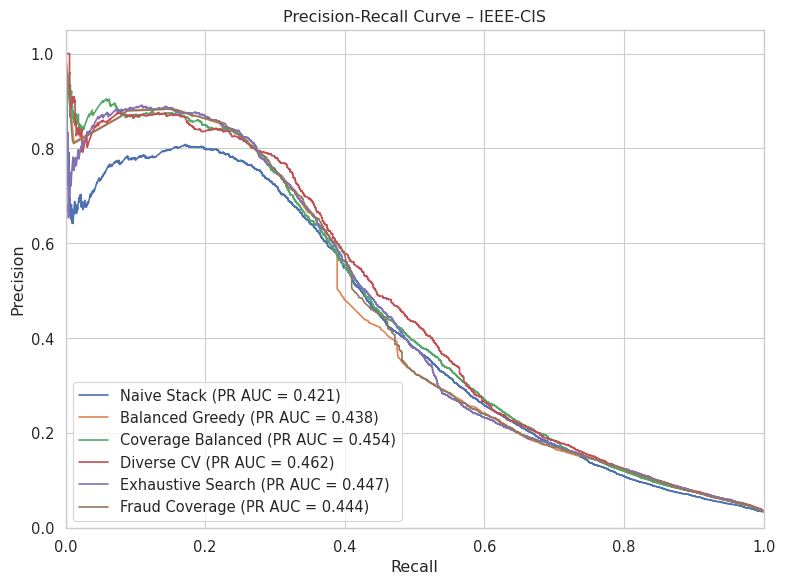

[save] trained/visualizations/pr_IEEE-CIS.png

[plot] ROC/PR for Sparkov


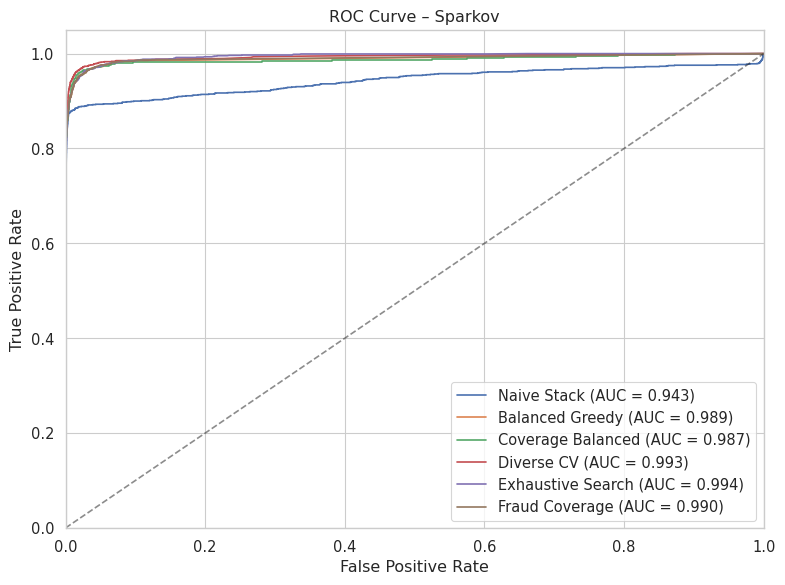

[save] trained/visualizations/roc_Sparkov.png


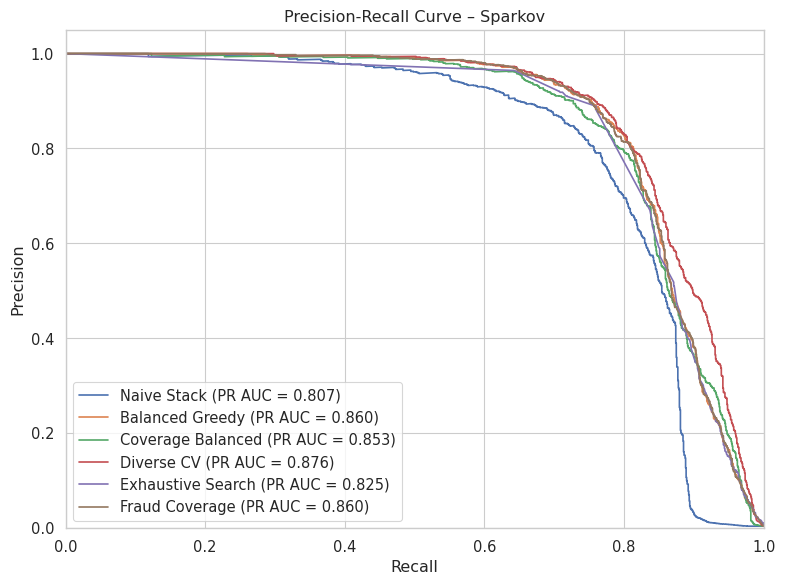

[save] trained/visualizations/pr_Sparkov.png


In [6]:
# =====================================================================
#  Figure 4: ROC & PR Curves per Dataset
# =====================================================================
def get_meta_learners(random_state=42):
    return {
        "LogisticRegression": LogisticRegression(C=1.0, max_iter=1000, random_state=random_state),
        "RidgeClassifier": RidgeClassifier(alpha=1.0, random_state=random_state),
        "RandomForest": RandomForestClassifier(
            n_estimators=200, max_depth=4, min_samples_leaf=10,
            random_state=random_state, n_jobs=-1
        ),
        "GaussianNB": GaussianNB(),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32), activation='relu',
            solver='adam', alpha=0.0001, max_iter=500,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10, random_state=random_state
        ),
        "LinearSVC": LinearSVC(C=1.0, max_iter=2000, random_state=random_state),
        "XGBoost": XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="auc", random_state=random_state,
            verbosity=0, use_label_encoder=False
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.05,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            random_state=random_state, verbose=-1, n_jobs=-1
        ),
    }

def load_probs_for_approach(dataset_name, strategy):
    """Return y_true, proba for a given strategy (including 'Naive Stack')."""
    if strategy == "Naive Stack":
        # Load best naive stack from leaderboard
        lb_file = Path(CONFIG["TRAINED_ROOT"]) / "leaderboards" / f"{dataset_name}_top3_L1_by_f1.csv"
        lb = pd.read_csv(lb_file)
        best = lb.loc[lb["f1"].idxmax()]
        variant = best["variant"]
        pred_file = Path(CONFIG["TRAINED_ROOT"]) / dataset_name / variant / "test_predictions.csv"
        if not pred_file.exists():
            return None, None
        pred_df = pd.read_csv(pred_file)
        return pred_df["y_true"].values, pred_df["stack_proba"].values

    # Optimized strategies (from unified table)
    row = comparison_df[(comparison_df["dataset"] == dataset_name) & 
                        (comparison_df["strategy"] == strategy)]
    if row.empty:
        return None, None
    row = row.iloc[0]
    strategy_key = [k for k, v in strategy_map.items() if v == strategy][0]  # reverse map
    meta_name = row["meta_learner"]

    out_dir = Path(CONFIG["TRAINED_ROOT"]) / "optimized_hybrid"
    val_meta = out_dir / f"{dataset_name}_{strategy_key}_selected_val_meta.csv"
    test_meta = out_dir / f"{dataset_name}_{strategy_key}_selected_test_meta.csv"
    labels_file = out_dir / f"{dataset_name}_selected_test_labels.csv"

    if not val_meta.exists() or not test_meta.exists() or not labels_file.exists():
        return None, None

    X_val = pd.read_csv(val_meta)
    X_test = pd.read_csv(test_meta)
    y_val = pd.read_csv(Path(CONFIG["DATA_ROOT"]) / f"{dataset_name}_val.csv")["Fraud"].values
    y_test = pd.read_csv(labels_file)["y_true"].values

    meta_learners = get_meta_learners(CONFIG["RANDOM_STATE"])
    meta = clone(meta_learners[meta_name])
    meta.fit(X_val, y_val)
    if hasattr(meta, "predict_proba"):
        proba = meta.predict_proba(X_test)[:, 1]
    elif hasattr(meta, "decision_function"):
        from scipy.special import expit
        proba = expit(meta.decision_function(X_test))
    else:
        return None, None
    return y_test, proba

# Reverse map for internal file naming
strategy_map_rev = {v: k for k, v in strategy_map.items()}
strategy_map_rev["Naive Stack"] = "naive_stack"

for ds in comparison_df["dataset"].unique():
    print(f"\n[plot] ROC/PR for {ds}")
    plt.figure(figsize=(8, 6))
    for strat in comparison_df["strategy"].unique():
        y_true, proba = load_probs_for_approach(ds, strat)
        if y_true is None or proba is None:
            print(f"  [skip] {strat} (data not available)")
            continue
        fpr, tpr, _ = roc_curve(y_true, proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{strat} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {ds}')
    plt.legend(loc="lower right")
    plt.tight_layout()
    roc_path = Path(CONFIG["OUTPUT_DIR"]) / f"roc_{ds}.png"
    plt.savefig(roc_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[save] {roc_path}")

    # PR curve
    plt.figure(figsize=(8, 6))
    for strat in comparison_df["strategy"].unique():
        y_true, proba = load_probs_for_approach(ds, strat)
        if y_true is None or proba is None:
            continue
        precision, recall, _ = precision_recall_curve(y_true, proba)
        pr_auc = average_precision_score(y_true, proba)
        plt.plot(recall, precision, label=f'{strat} (PR AUC = {pr_auc:.3f})')

    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve – {ds}')
    plt.legend(loc="lower left")
    plt.tight_layout()
    pr_path = Path(CONFIG["OUTPUT_DIR"]) / f"pr_{ds}.png"
    plt.savefig(pr_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[save] {pr_path}")

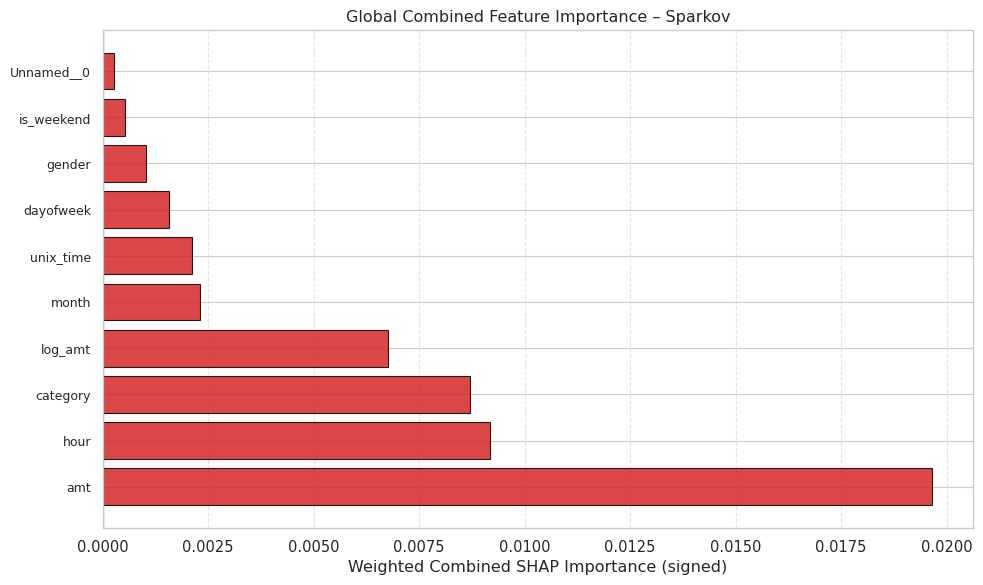

[save] trained/visualizations/global_shap_Sparkov.png


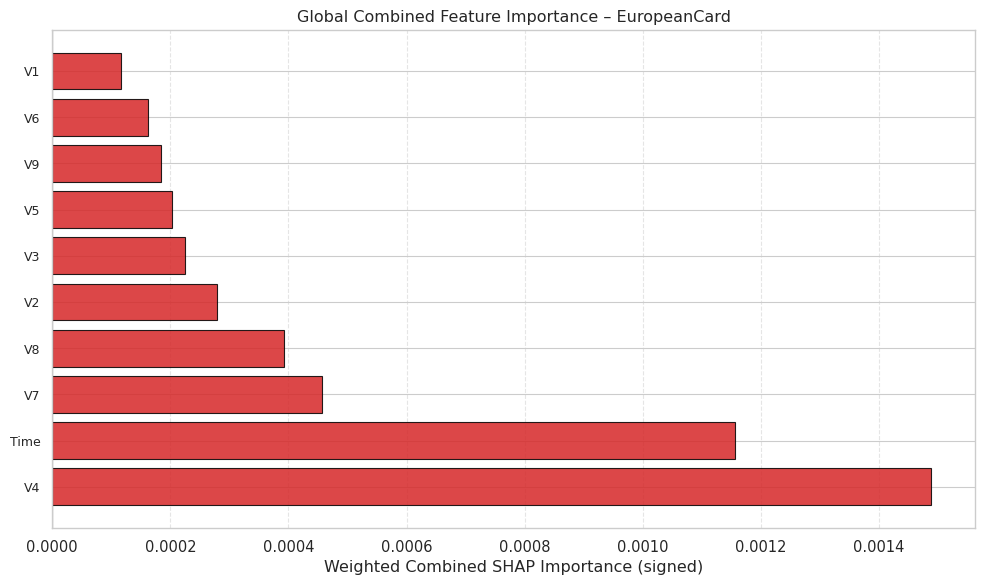

[save] trained/visualizations/global_shap_EuropeanCard.png


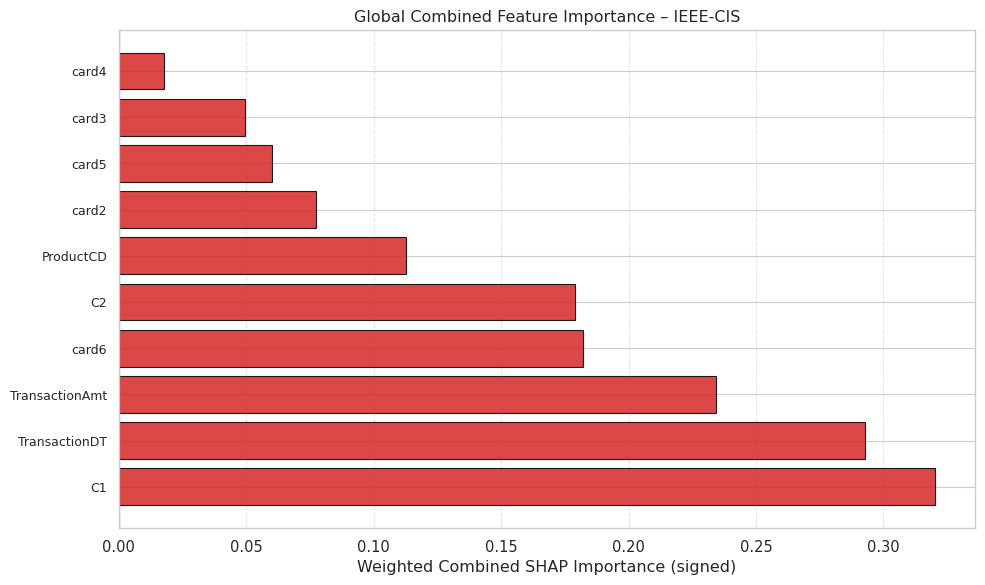

[save] trained/visualizations/global_shap_IEEE-CIS.png


In [8]:
# =====================================================================
# Figure 5: Global SHAP Combined Feature Importance (from XAI outputs)
# =====================================================================
xai_summary_path = Path(CONFIG["XAI_DIR"]) / "xai_summary.json"

if xai_summary_path.exists():
    with open(xai_summary_path, "r") as f:
        xai_summary = json.load(f)

    for ds, info in xai_summary.items():
        features = info.get("top_features", [])
        scores = info.get("combined_scores", [])

        if not features or not scores:
            print(f"  [skip] {ds}: no features/scores in xai_summary")
            continue

        # Sort by absolute score for better readability
        sorted_idx = np.argsort(np.abs(scores))[::-1]
        feat_sorted = [features[i] for i in sorted_idx]
        score_sorted = [scores[i] for i in sorted_idx]

        plt.figure(figsize=(10, max(4, 0.6 * len(feat_sorted))))
        colors = ['#d62728' if s >= 0 else '#1f77b4' for s in score_sorted]
        plt.barh(
            range(len(feat_sorted)),
            score_sorted,
            color=colors,
            edgecolor='black',
            alpha=0.85
        )
        plt.yticks(range(len(feat_sorted)), feat_sorted, fontsize=9)
        plt.xlabel("Weighted Combined SHAP Importance (signed)")
        plt.title(f"Global Combined Feature Importance – {ds}")
        plt.axvline(0, color='black', linewidth=0.8)
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()

        save_path = Path(CONFIG["OUTPUT_DIR"]) / f"global_shap_{ds}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"[save] {save_path}")

else:
    print(f"[skip] XAI summary not found at {xai_summary_path}.")
    print("Run XAI_framework.ipynb first to generate the summary.")